# 01 — Exploratory Data Analysis

**Phase 1** of the roadmap (`docs/DEVELOPMENT.md` §4). This notebook profiles each
dataset *exactly as published* — no cleaning, splitting, or label remapping (those
are Phase 2). All logic comes from `src/`; this notebook only orchestrates.

**Exit criterion (§4):** be able to describe each dataset in three sentences from
memory, with every EDA plot saved to `plots/eda/` at 300 DPI.

Datasets: **UCI** (structured features), **Mendeley n96ncsr5g4/1** (raw URLs),
**ISCX-URL2016** (raw URLs, registration-gated → may be pending).

In [1]:
import sys
from pathlib import Path

# Make `src` importable regardless of kernel cwd (repo root or notebooks/).
_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PLOTS_EDA_DIR, PLOT_DPI, RANDOM_SEED
from src.data.loaders import load_raw, available_datasets, is_available
from src.utils.seeds import set_all_seeds

set_all_seeds(RANDOM_SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = PLOT_DPI
PLOTS_EDA_DIR.mkdir(parents=True, exist_ok=True)

LEGIT_C, PHISH_C = "#2a9d8f", "#e76f51"


def save_fig(fig, name):
    """Save a figure to plots/eda/<name>.png at publication DPI."""
    out = PLOTS_EDA_DIR / f"{name}.png"
    fig.savefig(out, dpi=PLOT_DPI, bbox_inches="tight")
    print("saved", out.relative_to(REPO_ROOT))


# One summary row per dataset, consumed by the cross-dataset table at the end.
EDA_SUMMARY = []
print("datasets available:", available_datasets())

datasets available: ['uci', 'mendeley']


## 1. UCI Phishing Websites

11,055 instances described by 30 engineered, pre-discretized features (each in
{-1, 0, 1}) plus the `Result` label. **`Result = 1` is legitimate, `Result = -1`
is phishing.** This is the structured-feature baseline from the literature.

In [2]:
uci = load_raw("uci")
UCI_LABEL, UCI_PHISHING = "Result", -1   # Result: 1 = legitimate, -1 = phishing
feature_cols = [c for c in uci.columns if c != UCI_LABEL]

print("shape:", uci.shape)
print("n features:", len(feature_cols))
print("dtypes:", set(uci.dtypes.astype(str)))

# Fail loud (DEVELOPMENT.md §1.5): structured UCI must be all-integer in {-1,0,1}.
assert UCI_LABEL in uci.columns
assert set(np.unique(uci.values)).issubset({-1, 0, 1}), "UCI cells must be in {-1,0,1}"
uci.head()

shape: (11055, 31)
n features: 30
dtypes: {'int64'}


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


legitimate (Result=1): 6,157
phishing   (Result=-1): 4,898
phishing share: 44.3%


saved plots/eda/uci_class_distribution.png


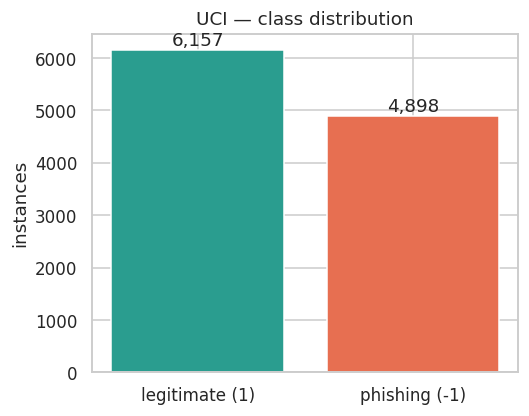

In [3]:
counts = uci[UCI_LABEL].value_counts().sort_index()
n = len(uci)
n_phish = int((uci[UCI_LABEL] == UCI_PHISHING).sum())
pct_phish = 100 * n_phish / n
print(f"legitimate (Result=1): {counts.get(1, 0):,}")
print(f"phishing   (Result=-1): {counts.get(-1, 0):,}")
print(f"phishing share: {pct_phish:.1f}%")

labels = ["legitimate (1)", "phishing (-1)"]
values = [int(counts.get(1, 0)), int(counts.get(-1, 0))]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, values, color=[LEGIT_C, PHISH_C])
ax.set_title("UCI — class distribution"); ax.set_ylabel("instances")
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
save_fig(fig, "uci_class_distribution"); plt.show()

In [4]:
n_missing = int(uci.isnull().sum().sum())
n_dup = int(uci.duplicated().sum())
print(f"missing values: {n_missing}")
print(f"exact-duplicate rows: {n_dup:,} ({100 * n_dup / n:.1f}%)")
print()
print("NOTE: the high duplicate count is EXPECTED — the 30 features are coarse")
print("discretizations in {-1,0,1}, so distinct websites collapse onto identical")
print("vectors. These are not true record duplicates and must not be dropped")
print("blindly; the handling decision belongs to Phase 2 preprocessing.")
uci[feature_cols].describe().T[["mean", "std", "min", "max"]].head(10)

missing values: 0
exact-duplicate rows: 5,206 (47.1%)

NOTE: the high duplicate count is EXPECTED — the 30 features are coarse
discretizations in {-1,0,1}, so distinct websites collapse onto identical
vectors. These are not true record duplicates and must not be dropped
blindly; the handling decision belongs to Phase 2 preprocessing.


,mean,std,min,max
having_IP_Address,0.313795,0.949534,-1.0,1.0
URL_Length,-0.633198,0.766095,-1.0,1.0
Shortining_Service,0.738761,0.673998,-1.0,1.0
having_At_Symbol,0.700588,0.713598,-1.0,1.0
double_slash_redirecting,0.741474,0.671011,-1.0,1.0
Prefix_Suffix,-0.734962,0.678139,-1.0,1.0
having_Sub_Domain,0.063953,0.817518,-1.0,1.0
SSLfinal_State,0.250927,0.911892,-1.0,1.0
Domain_registeration_length,-0.336771,0.941629,-1.0,1.0
Favicon,0.628584,0.777777,-1.0,1.0


Top features correlated with Result (sign = direction):
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
Domain_registeration_length   -0.225789
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718


saved plots/eda/uci_feature_label_correlation.png


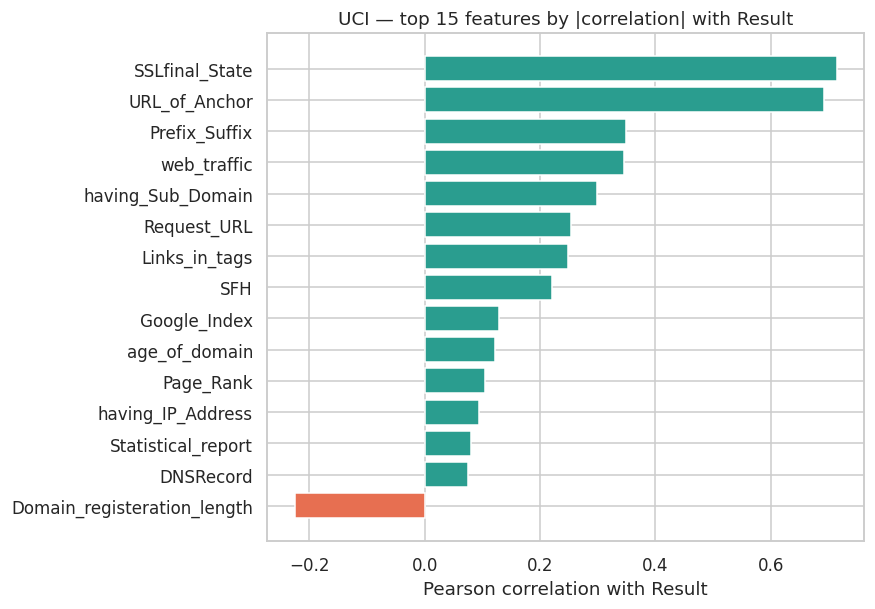

saved plots/eda/uci_correlation_heatmap.png


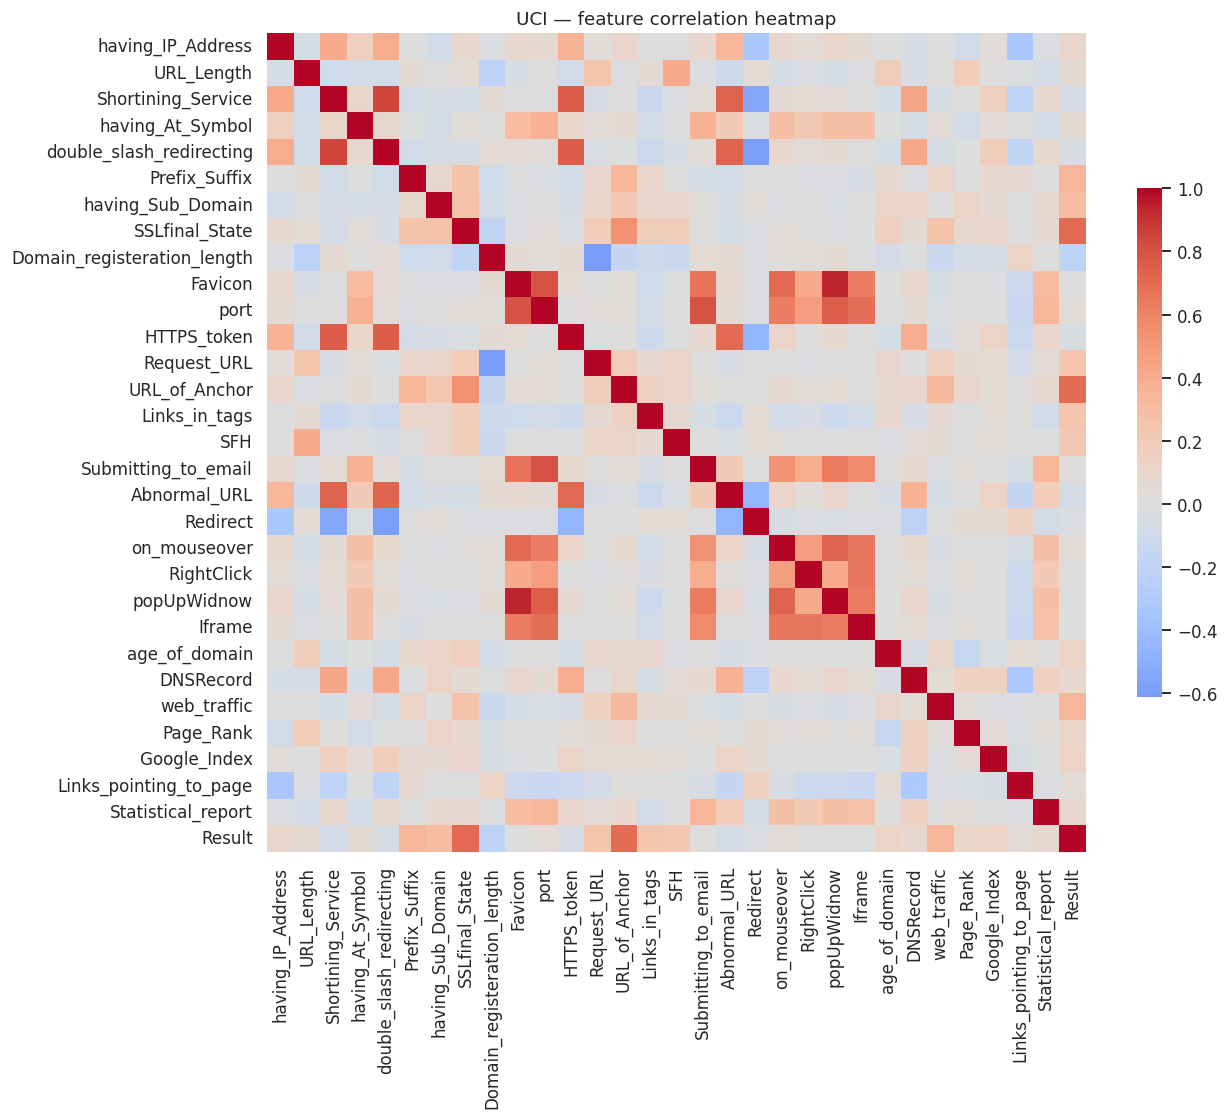

In [5]:
corr = uci.corr(numeric_only=True)
label_corr = corr[UCI_LABEL].drop(UCI_LABEL)
top = label_corr.reindex(label_corr.abs().sort_values(ascending=False).index).head(15)
print("Top features correlated with Result (sign = direction):")
print(top.to_string())

top_sorted = top.sort_values()
colors = [LEGIT_C if v > 0 else PHISH_C for v in top_sorted]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_sorted.index, top_sorted.values, color=colors)
ax.set_title("UCI — top 15 features by |correlation| with Result")
ax.set_xlabel("Pearson correlation with Result")
save_fig(fig, "uci_feature_label_correlation"); plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("UCI — feature correlation heatmap")
save_fig(fig, "uci_correlation_heatmap"); plt.show()

In [6]:
EDA_SUMMARY.append({
    "dataset": "UCI", "n_samples": n, "features": "30 structured (pm1)",
    "pct_phishing": round(pct_phish, 1),
    "pct_duplicates": round(100 * n_dup / n, 1),
    "pct_missing": round(100 * n_missing / (n * uci.shape[1]), 2),
})

## 2. Mendeley Phishing Websites Dataset (n96ncsr5g4/1)

80,000 instances of **raw URL + label** (`result`: 0 = legitimate, 1 = phishing).
The `website` column holds the *filename* of the captured HTML page; the HTML
*content* itself is not part of the published download (only `index.sql` ships).
This is the URL/text dataset for the Deep Learning and Transformer layers.

In [7]:
men = load_raw("mendeley")
MEN_LABEL, MEN_PHISHING = "result", 1   # result: 0 = legitimate, 1 = phishing
print("shape:", men.shape)
print("columns:", list(men.columns))
assert {"url", "website", "result"}.issubset(men.columns)
assert men["url"].isnull().sum() == 0, "unexpected null URLs"

# D-003 schema confirmation: URL + label present; HTML *content* is not.
has_html_content = men["website"].astype(str).str.contains("<html", case=False, na=False).any()
print()
print("D-003 schema check:")
print("  raw URL column present :", "url" in men.columns)
print("  HTML *content* present :", bool(has_html_content), "(expected False — only filenames ship)")
men.head(4)

shape: (80000, 5)
columns: ['rec_id', 'url', 'website', 'result', 'created_date']

D-003 schema check:
  raw URL column present : True
  HTML *content* present : False (expected False — only filenames ship)


,rec_id,url,website,result,created_date
0,1,http://intego3.info/EXEL/index.php,1613573972338075.html,1,2021-02-17 20:29:32
1,2,https://www.mathopenref.com/segment.html,1635698138155948.html,0,2021-10-31 16:35:38
2,3,https://www.computerhope.com/issues/ch000254.htm,1635699228889266.html,0,2021-10-31 16:53:48
3,4,https://www.investopedia.com/terms/n/next-elev...,1635750062162701.html,0,2021-11-01 12:31:02


legitimate (0): 50,000
phishing   (1): 30,000
phishing share: 37.5%


saved plots/eda/mendeley_class_distribution.png


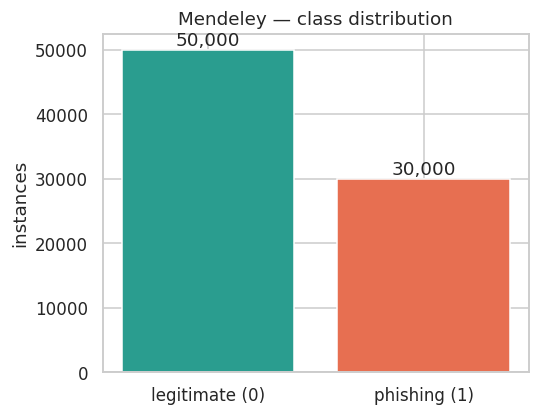

In [8]:
counts = men[MEN_LABEL].value_counts().sort_index()
n = len(men)
n_phish = int((men[MEN_LABEL] == MEN_PHISHING).sum())
pct_phish = 100 * n_phish / n
print(f"legitimate (0): {counts.get(0, 0):,}")
print(f"phishing   (1): {counts.get(1, 0):,}")
print(f"phishing share: {pct_phish:.1f}%")

labels = ["legitimate (0)", "phishing (1)"]
values = [int(counts.get(0, 0)), int(counts.get(1, 0))]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, values, color=[LEGIT_C, PHISH_C])
ax.set_title("Mendeley — class distribution"); ax.set_ylabel("instances")
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
save_fig(fig, "mendeley_class_distribution"); plt.show()

            mean  median  min   max
result                             
legitimate  58.3    52.0   14  1389
phishing    73.1    50.0   13  1641
p95 overall: 136


saved plots/eda/mendeley_url_length_by_class.png


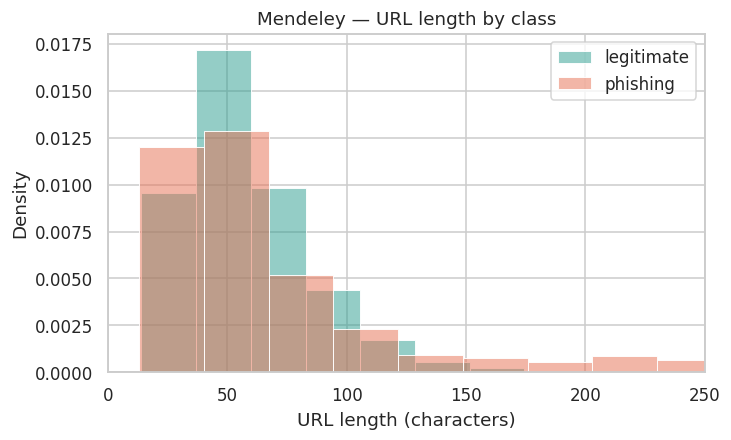

note: x-axis clipped at 250 for legibility; max length is 1641


In [9]:
men["url_length"] = men["url"].astype(str).str.len()
stats = men.groupby(MEN_LABEL)["url_length"].agg(["mean", "median", "min", "max"]).round(1)
stats.index = stats.index.map({0: "legitimate", 1: "phishing"})
print(stats.to_string())
print("p95 overall:", int(men["url_length"].quantile(0.95)))

fig, ax = plt.subplots(figsize=(7, 4))
for label, color, name in [(0, LEGIT_C, "legitimate"), (1, PHISH_C, "phishing")]:
    sns.histplot(men.loc[men[MEN_LABEL] == label, "url_length"], bins=60,
                 color=color, label=name, stat="density", alpha=0.5, ax=ax)
ax.set_xlim(0, 250)
ax.set_title("Mendeley — URL length by class")
ax.set_xlabel("URL length (characters)"); ax.legend()
save_fig(fig, "mendeley_url_length_by_class"); plt.show()
print("note: x-axis clipped at 250 for legibility; max length is", int(men["url_length"].max()))

In [10]:
n_missing = int(men.drop(columns=["url_length"]).isnull().sum().sum())
n_dup_url = int(men["url"].duplicated().sum())
print(f"missing values: {n_missing}")
print(f"duplicate URLs: {n_dup_url:,} ({100 * n_dup_url / n:.2f}%)")
print()
for label, name in [(0, "LEGITIMATE"), (1, "PHISHING")]:
    print(f"--- 10 representative {name} URLs ---")
    sample = men.loc[men[MEN_LABEL] == label, "url"].sample(10, random_state=RANDOM_SEED)
    for u in sample:
        print("  ", (u[:97] + "...") if len(u) > 100 else u)
    print()

EDA_SUMMARY.append({
    "dataset": "Mendeley", "n_samples": n, "features": "raw URL (+HTML filename)",
    "pct_phishing": round(pct_phish, 1),
    "pct_duplicates": round(100 * n_dup_url / n, 2),
    "pct_missing": round(100 * n_missing / (n * (men.shape[1] - 1)), 2),
})

missing values: 0
duplicate URLs: 152 (0.19%)

--- 10 representative LEGITIMATE URLs ---
   https://archive.lib.msu.edu/crcmath/math/math/s/s561.htm
   https://www.dell.com:443/community/Laptops-General-Read-Only/Dell-Inspiron-1420-display-resolutio...
   https://www.calculator.net/mortgage-calculator.html
   https://businesshelp.snapchat.com/s/article/payment-methods
   http://www.sthda.com/english/wiki/text-mining-and-word-cloud-fundamentals-in-r-5-simple-steps-you...
   https://www.micahsingapore.org/micahconversation2019
   https://ansamcal.com/
   https://www.amybd.com/nsite/index?v=987654357
   http://fcit.usf.edu/NETWORK/chap2/chap2.htm
   https://www.mirc.com/

--- 10 representative PHISHING URLs ---
   https://atendimento-pg-series.joomla.com/br/netflix/index.php?q=2sptq6sf2spt-zkat-2sptzkatzkat-1a...
   https://www.hm.rc-verify5.com/main/index.html
   https://www.eospo.cearcod.com/
   https://docs.google.com/forms/d/e/1FAIpQLSeKqIiAMpP-OsUImmsrqlBnEM4RUkmazsORFws3paRS6RPmyQ/v

## 3. ISCX-URL2016

Distributed by UNB CIC behind a registration form, so it is **not** auto-downloaded
(see `scripts/download_datasets.sh`). This section runs only if the CSV is present;
otherwise it reports the dataset as pending. ISCX is reserved for the cross-dataset
generalization test (Phase 6).

In [11]:
if is_available("iscx"):
    iscx = load_raw("iscx")
    print("shape:", iscx.shape)
    print("columns:", list(iscx.columns))
    # ISCX-URL2016 is multi-class (Benign/Defacement/malware/phishing/spam);
    # surface a label-like column heuristically.
    label_like = [c for c in iscx.columns
                  if iscx[c].dtype == object and iscx[c].nunique() <= 10]
    if label_like:
        col = label_like[0]
        print(f"class-like column '{col}':")
        print(iscx[col].value_counts())
    print("NOTE: binary mapping (phishing vs non-phishing) is a Phase 2 decision.")
else:
    print("ISCX-URL2016 not present — pending manual download.")
    print("See scripts/download_datasets.sh for the registration-form steps.")

ISCX-URL2016 not present — pending manual download.
See scripts/download_datasets.sh for the registration-form steps.


## 4. Cross-dataset summary

          n_samples                  features  pct_phishing  pct_duplicates  pct_missing
dataset                                                                                 
UCI           11055       30 structured (pm1)          44.3           47.10          0.0
Mendeley      80000  raw URL (+HTML filename)          37.5            0.19          0.0


saved plots/eda/cross_dataset_class_balance.png


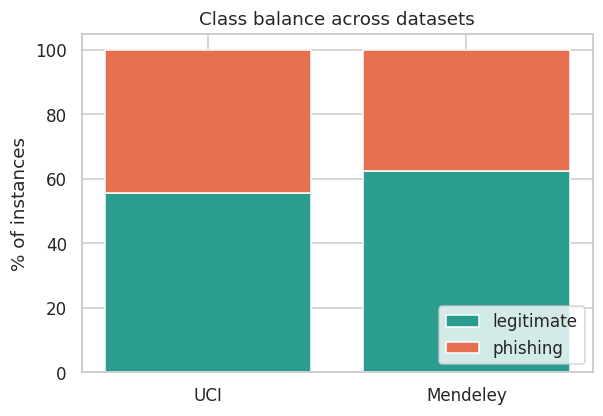

In [12]:
summary_df = pd.DataFrame(EDA_SUMMARY).set_index("dataset")
print(summary_df.to_string())

present = summary_df.index.tolist()
x = np.arange(len(present))
legit = [100 - summary_df.loc[d, "pct_phishing"] for d in present]
phish = [summary_df.loc[d, "pct_phishing"] for d in present]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, legit, label="legitimate", color=LEGIT_C)
ax.bar(x, phish, bottom=legit, label="phishing", color=PHISH_C)
ax.set_xticks(x); ax.set_xticklabels(present)
ax.set_ylabel("% of instances"); ax.set_title("Class balance across datasets")
ax.legend(loc="lower right")
save_fig(fig, "cross_dataset_class_balance"); plt.show()

## 5. Three-sentence descriptions (Phase 1 exit criterion)

**UCI Phishing Websites.** 11,055 websites described by 30 pre-engineered features
discretized to {-1, 0, 1} plus a `Result` label (1 = legitimate, -1 = phishing),
serving as the structured-feature baseline. Classes are moderately balanced
(~55.7% legitimate / 44.3% phishing) with zero missing values. ~47% of rows are
exact duplicates because the coarse features collapse distinct sites onto identical
vectors — a preprocessing nuance, not corrupt data.

**Mendeley Phishing Websites (n96ncsr5g4/1).** 80,000 raw URLs with a binary label
(0 = legitimate / 1 = phishing), split 50,000 / 30,000 (~37.5% phishing). The
published download is the `index.sql` index only — URLs, HTML *filenames*, and
labels — so HTML page *content* is not available, but the raw URLs feed the
character-level DL and Transformer layers directly. URLs span 13–1,641 characters
(median 51, p95 ~136) with negligible duplication.

**ISCX-URL2016.** A registration-gated UNB CIC dataset of classified raw URLs
(~36,000; multi-class: benign/defacement/malware/phishing/spam) reserved for the
cross-dataset generalization test. It is not auto-downloadable and is currently
pending a manual fetch; once present, this notebook profiles its class breakdown
and URL lengths like the Mendeley section.